In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

In [6]:
df = pd.read_excel("Online Retail.xlsx")

In [9]:
print(df.head())
print("_____________________________________________")
print(df.info())
print("_____________________________________________")
print(df.shape)
print("_____________________________________________")
print(df.columns)

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
_____________________________________________
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype    

In [10]:
print("Missing Values")
print(df.isnull().sum())

print("\nDuplicate Rows")
print(df.duplicated().sum())

Missing Values
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Duplicate Rows
5268


In [11]:
df = df.dropna(subset=['CustomerID'])

In [12]:
df = df.dropna(subset=['Description'])

In [13]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [14]:
df = df[df['Quantity'] > 0]

In [15]:
df = df[df['UnitPrice'] > 0]

In [16]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [17]:
df['Sales'] = df['Quantity'] * df['UnitPrice']

In [18]:
df['Month'] = df['InvoiceDate'].dt.month

In [19]:
df['Year'] = df['InvoiceDate'].dt.year

In [20]:
print("Total Sales =", df['Sales'].sum())

Total Sales = 8911407.904


In [21]:
print("Total Orders =", df['InvoiceNo'].nunique())

Total Orders = 18532


In [22]:
print("Total Customers =", df['CustomerID'].nunique())

Total Customers = 4338


In [23]:
avg_order = df.groupby('InvoiceNo')['Sales'].sum().mean()

print(avg_order)

480.8659563997409


In [24]:
print(df['Sales'].max())

168469.6


In [25]:
print(df['Sales'].min())

0.001


In [26]:
print(df['Sales'].mean())

22.396999889415003


In [27]:
print(df['Sales'].median())

11.8


In [28]:
print(df['Sales'].mode())

0    15.0
Name: Sales, dtype: float64


In [29]:
print(df['Sales'].std())

309.0710414140188


In [30]:
top_products = df.groupby('Description')['Sales'].sum()

top_products = top_products.sort_values(ascending=False)

print(top_products.head(10))

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142592.95
WHITE HANGING HEART T-LIGHT HOLDER    100448.15
JUMBO BAG RED RETROSPOT                85220.78
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68844.33
ASSORTED COLOUR BIRD ORNAMENT          56580.34
Manual                                 53779.93
RABBIT NIGHT LIGHT                     51346.20
Name: Sales, dtype: float64


In [31]:
print(top_products.tail(10))

Description
PACK 4 FLOWER/BUTTERFLY PATCHES        1.250
60 GOLD AND SILVER FAIRY CAKE CASES    1.100
CAT WITH SUNGLASSES BLANK CARD         0.950
HAPPY BIRTHDAY CARD TEDDY/CAKE         0.950
PINK CRYSTAL GUITAR PHONE CHARM        0.850
PURPLE FRANGIPANI HAIRCLIP             0.850
VINTAGE BLUE TINSEL REEL               0.840
SET 12 COLOURING PENCILS DOILEY        0.650
HEN HOUSE W CHICK IN NEST              0.420
PADS TO MATCH ALL CUSHIONS             0.003
Name: Sales, dtype: float64


In [32]:
top_customers = df.groupby('CustomerID')['Sales'].sum()

top_customers = top_customers.sort_values(ascending=False)

print(top_customers.head(10))

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194550.79
16446.0    168472.50
14911.0    143825.06
12415.0    124914.53
14156.0    117379.63
17511.0     91062.38
16029.0     81024.84
12346.0     77183.60
Name: Sales, dtype: float64


In [33]:
buyers = df.groupby('CustomerID')['InvoiceNo'].count()

buyers = buyers.sort_values(ascending=False)

print(buyers.head(10))

CustomerID
17841.0    7847
14911.0    5675
14096.0    5111
12748.0    4595
14606.0    2700
15311.0    2379
14646.0    2076
13089.0    1818
13263.0    1677
14298.0    1637
Name: InvoiceNo, dtype: int64


In [34]:
country_sales = df.groupby('Country')['Sales'].sum()

country_sales = country_sales.sort_values(ascending=False)

print(country_sales)

Country
United Kingdom          7308391.554
Netherlands              285446.340
EIRE                     265545.900
Germany                  228867.140
France                   209024.050
Australia                138521.310
Spain                     61577.110
Switzerland               56443.950
Belgium                   41196.340
Sweden                    38378.330
Japan                     37416.370
Norway                    36165.440
Portugal                  33439.890
Finland                   22546.080
Singapore                 21279.290
Channel Islands           20450.440
Denmark                   18955.340
Italy                     17483.240
Cyprus                    13590.380
Austria                   10198.680
Poland                     7334.650
Israel                     7221.690
Greece                     4760.520
Iceland                    4310.000
Canada                     3666.380
USA                        3580.390
Malta                      2725.590
Unspecified         

In [35]:
print(country_sales.idxmax())

United Kingdom


In [36]:
print(country_sales.idxmin())

Saudi Arabia


In [37]:
monthly_sales = df.groupby('Month')['Sales'].sum()

print(monthly_sales)

Month
1      569445.040
2      447137.350
3      595500.760
4      469200.361
5      678594.560
6      661213.690
7      600091.011
8      645343.900
9      952838.382
10    1039318.790
11    1161817.380
12    1090906.680
Name: Sales, dtype: float64


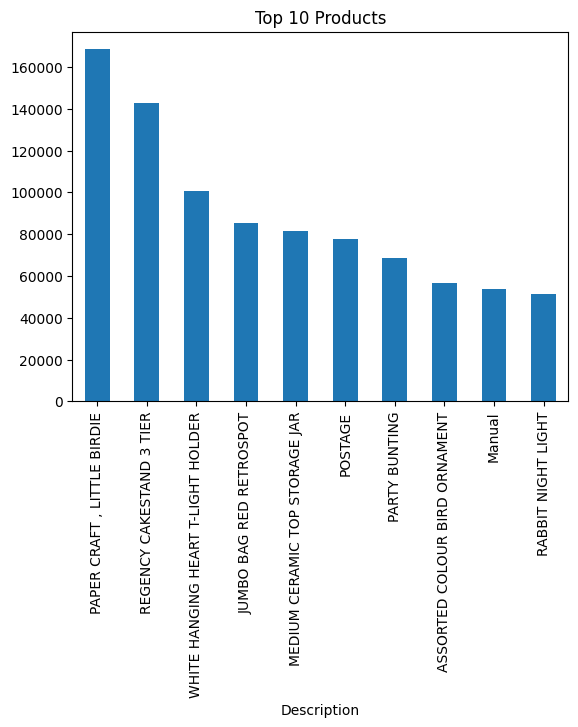

In [38]:
top_products.head(10).plot(kind='bar')

plt.title("Top 10 Products")

plt.show()

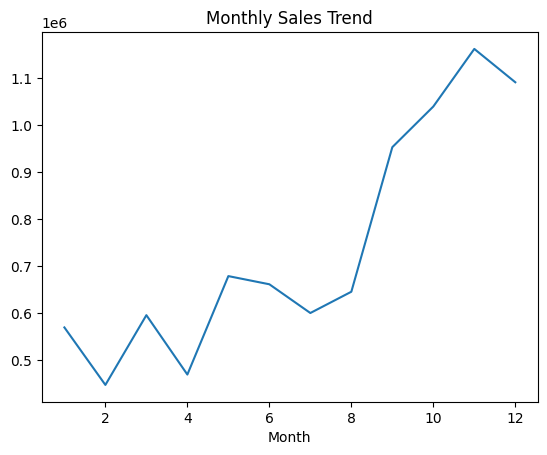

In [39]:
monthly_sales.plot(kind='line')

plt.title("Monthly Sales Trend")

plt.show()

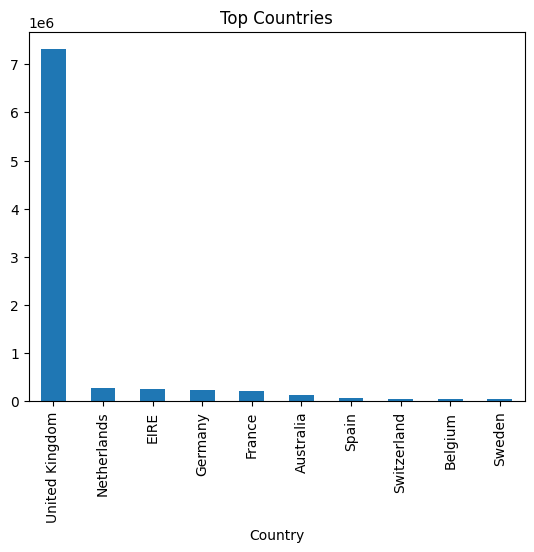

In [40]:
country_sales.head(10).plot(kind='bar')

plt.title("Top Countries")

plt.show()

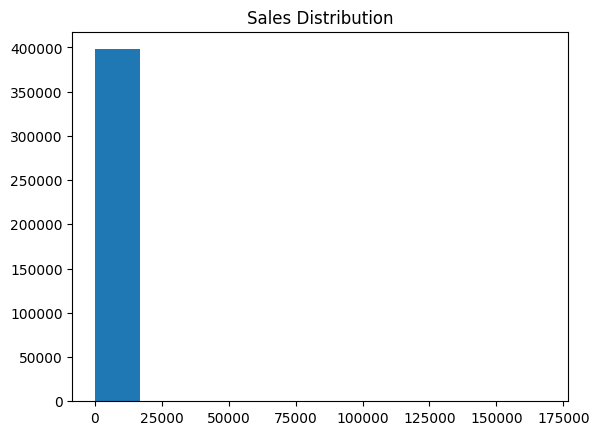

In [41]:
plt.hist(df['Sales'])

plt.title("Sales Distribution")

plt.show()

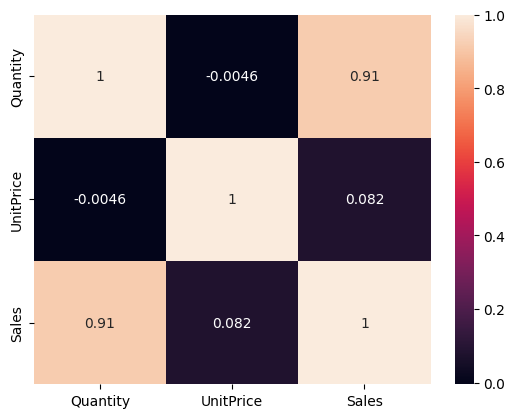

In [43]:
sb.heatmap(df[['Quantity','UnitPrice','Sales']].corr(),
           annot=True)

plt.show()

In [44]:
df.to_csv("cleaned_sales_data.csv",
          index=False)

In [47]:
f = open("report.txt","w")

f.write("SALES DASHBOARD REPORT\n")

f.write(f"\nTotal Sales: {df['Sales'].sum()}")

f.write(f"\nTotal Customers: {df['CustomerID'].nunique()}")

f.write(f"\nTotal Orders: {df['InvoiceNo'].nunique()}")

f.close()

In [48]:
with open("report1.txt", "w") as f:

    f.write("="*50)
    f.write("\nADVANCED SALES DATA ANALYSIS REPORT")
    f.write("\n" + "="*50)

    f.write(f"\n\nTotal Sales: {df['Sales'].sum():.2f}")

    f.write(f"\nTotal Orders: {df['InvoiceNo'].nunique()}")

    f.write(f"\nTotal Customers: {df['CustomerID'].nunique()}")

    f.write(f"\nAverage Sale: {df['Sales'].mean():.2f}")

    f.write(f"\nMaximum Sale: {df['Sales'].max():.2f}")

    f.write(f"\nMinimum Sale: {df['Sales'].min():.2f}")

    f.write(f"\nMedian Sale: {df['Sales'].median():.2f}")

    f.write(f"\nStandard Deviation: {df['Sales'].std():.2f}")

    f.write("\n\nTOP 5 PRODUCTS")
    f.write("\n" + "-"*30)

    top_products = df.groupby('Description')['Sales'].sum().sort_values(ascending=False)

    for product, sales in top_products.head(5).items():
        f.write(f"\n{product} : {sales:.2f}")

    f.write("\n\nTOP 5 CUSTOMERS")
    f.write("\n" + "-"*30)

    top_customers = df.groupby('CustomerID')['Sales'].sum().sort_values(ascending=False)

    for customer, sales in top_customers.head(5).items():
        f.write(f"\nCustomer {customer} : {sales:.2f}")

    f.write("\n\nTOP 5 COUNTRIES")
    f.write("\n" + "-"*30)

    country_sales = df.groupby('Country')['Sales'].sum().sort_values(ascending=False)

    for country, sales in country_sales.head(5).items():
        f.write(f"\n{country} : {sales:.2f}")

    f.write("\n\nDATA QUALITY REPORT")
    f.write("\n" + "-"*30)

    f.write(f"\nMissing Values: {df.isnull().sum().sum()}")

    f.write(f"\nDuplicate Records: {df.duplicated().sum()}")

    f.write(f"\nTotal Records: {len(df)}")

    f.write("\n\nREPORT GENERATED SUCCESSFULLY")

SyntaxError: invalid syntax (3884930397.py, line 1)